We shall find the ground state and higher modes for the infinite square well system :

### Solving the ODE :

$$ y'' + \lambda y = 0 $$

with BC(s) :

$$ y(0) = y(\pi) = 0 $$

The domain of the problem is : $[0,\pi]$

### Exact Solutions :

$$ \lambda = n^2 $$

for $n\in \mathbb{N}$

with corresponding solutions :

$$ y = \sin(nx) $$

### Note : 

To ensure the trivial $y = 0$ solution and avoid solutions with arbitrary amplitudes, we put an additional normalisation condition :

$$ \dfrac{1}{\pi}\int_0^{\pi} y^2(x) dx = 1 $$

To avoid evaluating integrals numerically, we shall instead use :

$$ \dfrac{1}{N}\sum^N_i y(x_i)^2 = 1 $$

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
# domain
N = 101
x = torch.linspace(0,torch.pi,N,requires_grad=True).reshape(-1,1)

In [3]:
# Model
model = nn.Sequential(
    nn.Linear(1,20),
    nn.Tanh(),
    nn.Linear(20,20),
    nn.Tanh(),
    nn.Linear(20,1)
)

### Loss 1 : Without Orthogonality :

We shall first see what happens if we choose $\lambda$ arbitrarily.

In [4]:
# Loss function
def Loss(model,x,lmda):
    y = model(x)

    # gradients
    dydx = torch.autograd.grad(
        outputs = y,
        inputs = x,
        create_graph = True,
        grad_outputs = torch.ones_like(y)
    )[0]

    d2ydx2 = torch.autograd.grad(
        outputs = dydx,
        inputs = x,
        create_graph = True,
        grad_outputs = torch.ones_like(dydx)
    )[0]

    # ode loss
    loss_ode = torch.mean((d2ydx2 + lmda*y)**2)

    # BC loss
    loss_bc = (y[0])**2 + (y[-1])**2

    # normalization loss
    loss_norm = (torch.mean(y**2)-1)**2

    return loss_ode + loss_norm + loss_bc

In [5]:
def solve_eig_ODE(Loss,lmda,N_epochs):

    # optimizer
    optim = torch.optim.Adam(list(model.parameters())+[lmda],lr = 0.01)

    # training the PINN
    loss_arr = []
    for epoch in range(N_epochs):
        # feed forward and loss
        loss = Loss(model,x,lmda)
        loss_arr.append(loss.item())

        # optimization
        loss.backward()
        optim.step()
        optim.zero_grad()
    
    # PINN function
    with torch.no_grad():
        y_PINN = model(x)

    return y_PINN, loss_arr

In [6]:
# Initialization
N_epochs = 100000
# Lambda as a trainable parameter
lmda = nn.Parameter(torch.tensor([10.0]))

# training the function
y_PINN, loss_arr = solve_eig_ODE(Loss,lmda,N_epochs)

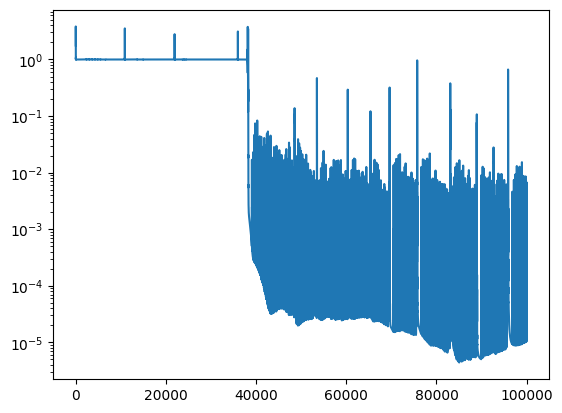

In [7]:
# loss visualisation
plt.semilogy(loss_arr)
plt.show()

Text(0, 0.5, 'y values')

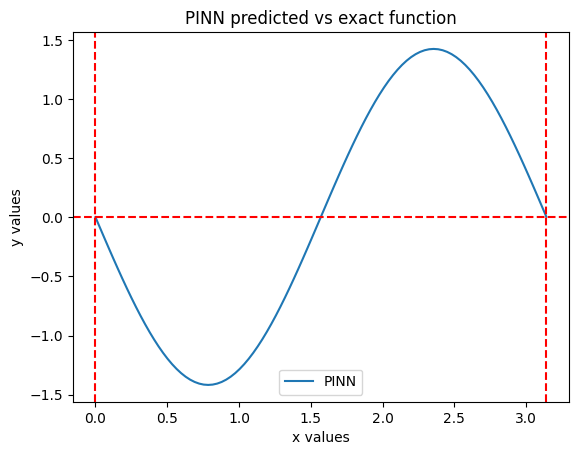

In [8]:
# comparing the PINN against the exact function
plt.plot(x.flatten().detach(),y_PINN.flatten().detach(),label = 'PINN')
plt.axhline(0,c = 'red',ls = '--')
plt.axvline(0,c = 'red',ls = '--')
plt.axvline(torch.pi,c = 'red',ls = '--')
plt.legend()
plt.title("PINN predicted vs exact function")
plt.xlabel("x values")
plt.ylabel("y values")

# Remarks :

It so happened that even after starting with $\lambda = 10.0$ which is closer to the second mode ($ \lambda = 4.0 $), the model learns the 1-st mode. To avoid learning the easiest modes (lower modes) always, we shall include another the term in the loss function i.e. the orthogonality loss.

Orthogonality condition :

$$ \int y_1(x)y_2(x)dx = 0 $$

For the Neural Net, we can implement :

$$ \dfrac{1}{N}\sum_{i=1}^N y_1(x_i)y_2(x_i) = 0 $$

In [26]:
# defining the model
def make_model():
    model = nn.Sequential(
        nn.Linear(1,20),
        nn.Tanh(),
        nn.Linear(20,20),
        nn.Tanh(),
        nn.Linear(20,1)
    )

In [ ]:
def solve_eig_ODE_modified(Loss,lmda,N_epochs,prev_solns = []):
    # model
    model = make_model()

    # optimizer
    optim = torch.optim.Adam(list(model.parameters())+[lmda],lr = 0.01)

    # training the PINN
    loss_arr = []
    for epoch in range(N_epochs):
        # feed forward and loss
        loss = Loss_modified(model,x,lmda,prev_solns)
        loss_arr.append(loss.item())

        # optimization
        loss.backward()
        optim.step()
        optim.zero_grad()
    
    # PINN function
    with torch.no_grad():
        y_PINN = model(x)

    return y_PINN, loss_arr

In [ ]:
# modified loss function
def Loss_modified(model,x,lmda,prev_solns):
    y = model(x)

    # gradients
    dydx = torch.autograd.grad(
        outputs = y,
        inputs = x,
        create_graph = True,
        grad_outputs = torch.ones_like(y)
    )[0]

    d2ydx2 = torch.autograd.grad(
        outputs = dydx,
        inputs = x,
        create_graph = True,
        grad_outputs = torch.ones_like(dydx)
    )[0]

    # ode loss
    loss_ode = torch.mean((d2ydx2 + lmda*y)**2)

    # BC loss
    loss_bc = (y[0])**2 + (y[-1])**2

    # normalization loss
    loss_norm = (torch.mean(y**2)-1)**2

    # orthogonality loss
    for y

    loss_orth = (torch.mean(y1.detach()*y))**2

    return loss_ode + loss_norm + loss_bc + loss_orth

### Finding the lowest mode : ($\lambda$ = 1.0)

In [16]:
# we shall start with a low lambda value
N_epochs = 10000
lmda = nn.Parameter(torch.tensor([0.0]))
y1, loss_arr = solve_eig_ODE(Loss,lmda,N_epochs)

In [17]:
# eigenvalue
print(f"Eigenvalue : {lmda.item()}")
print(f"n : {lmda.item()**0.5}")

Eigenvalue : 1.000074863433838
n : 1.0000374310163784


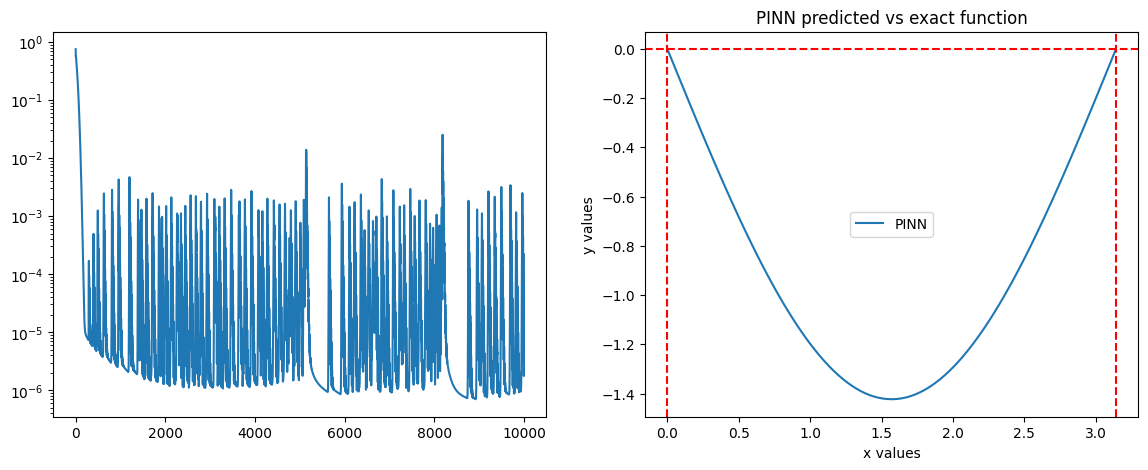

In [18]:
# visualisation
plt.figure(figsize = (14,5))

plt.subplot(1,2,1)
plt.semilogy(loss_arr)

plt.subplot(1,2,2)
plt.plot(x.flatten().detach(),y1.flatten().detach(),label = 'PINN')
plt.axhline(0,c = 'red',ls = '--')
plt.axvline(0,c = 'red',ls = '--')
plt.axvline(torch.pi,c = 'red',ls = '--')
plt.legend()
plt.title("PINN predicted vs exact function")
plt.xlabel("x values")
plt.ylabel("y values")

plt.show()

### Finding the second model ($\lambda = 4.0$)

In [19]:
# modified loss function
def Loss_second_mode(model,x,lmda):
    y = model(x)

    # gradients
    dydx = torch.autograd.grad(
        outputs = y,
        inputs = x,
        create_graph = True,
        grad_outputs = torch.ones_like(y)
    )[0]

    d2ydx2 = torch.autograd.grad(
        outputs = dydx,
        inputs = x,
        create_graph = True,
        grad_outputs = torch.ones_like(dydx)
    )[0]

    # ode loss
    loss_ode = torch.mean((d2ydx2 + lmda*y)**2)

    # BC loss
    loss_bc = (y[0])**2 + (y[-1])**2

    # normalization loss
    loss_norm = (torch.mean(y**2)-1)**2

    # orthogonality loss
    loss_orth = (torch.mean(y1.detach()*y))**2

    return loss_ode + loss_norm + loss_bc + loss_orth

In [23]:
# we shall start with a low lambda value
N_epochs = 10000
lmda = nn.Parameter(torch.tensor([2.0]))
y2, loss_arr = solve_eig_ODE(Loss_second_mode,lmda,N_epochs)

In [24]:
# eigenvalue
print(f"Eigenvalue : {lmda.item()}")
print(f"n : {lmda.item()**0.5}")

Eigenvalue : 1.000218391418457
n : 1.0001091897480279


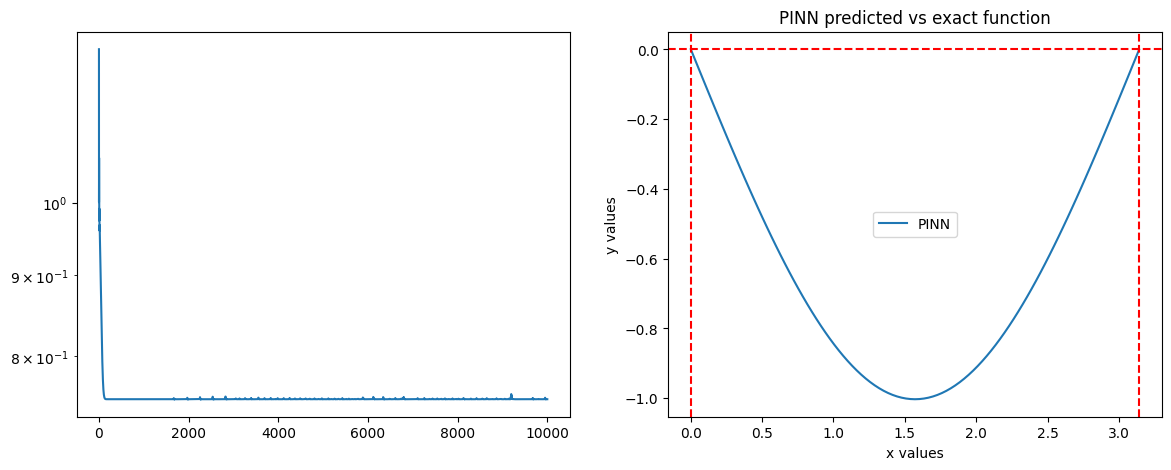

In [25]:
# visualisation
plt.figure(figsize = (14,5))

plt.subplot(1,2,1)
plt.semilogy(loss_arr)

plt.subplot(1,2,2)
plt.plot(x.flatten().detach(),y2.flatten().detach(),label = 'PINN')
plt.axhline(0,c = 'red',ls = '--')
plt.axvline(0,c = 'red',ls = '--')
plt.axvline(torch.pi,c = 'red',ls = '--')
plt.legend()
plt.title("PINN predicted vs exact function")
plt.xlabel("x values")
plt.ylabel("y values")

plt.show()